In [79]:
import numpy as np
from collections import defaultdict


In [80]:
# I. Defining State Space and Dice Outcomes
## Goal:
## - Create a clear state indexing scheme
## - Create a table of all 36 outcomes with probabilities

In [81]:
#-------- Board Constants --------#
NUM_POS = 40
GO = 0
JAIL = 10
GOTO_JAIL = 30

CHANCE = {7, 22, 36}
CHEST  = {2, 17, 33}

RAILS = [5, 15, 25, 35]
UTILS = [12, 28]

#-------- Community Chest --------#
# 16 cards total including 2 movement cards
# 'Advance to Go', 'Go to Jail'
CC_MOVE = {GO: 1/16, "JAIL_STATE": 1/16}
CC_STAY = 14/16

#-------- Chance  --------#
# 16 cards total including 10 movement cards
# 6 Fixed: Go, Jail, Illinois Ave.(24), St. Charles(11), Boardwalk(39), Reading RR(5)
# 4 Non-fixed: 2x Nearest railroad, nearest utility, move back 3 spaces
CH_FIXED = [GO, "JAIL_STATE", 24, 11, 39, 5]

CH_P_FIXED = len(CH_FIXED) / 16
CH_P_NEAREST_RR = 2/16
CH_P_NEAREST_U = 1/16
CH_P_BACK3 = 1/16
CH_STAY = 6/16

In [82]:
#-------- Helper Functions --------#
def goto_jail(pos):
    return "JAIL_STATE" if pos == GOTO_JAIL else pos

def next_railroad(pos):
    for r in RAILS:
        if r > pos:
            return r
    return RAILS[0]

def next_utility(pos):
    for u in UTILS:
        if u > pos:
            return u
    return UTILS[0]

# After moving onto a 'pos', this function returns a distribution of all outcomes
def resolve_pos_distribution(pos) -> dict:
    # 1) Go to jail
    if pos == GOTO_JAIL:
        return {"JAIL_STATE" : 1.0}

    # 2) Community Chest
    if pos in CHEST:
        temp = defaultdict(float)
        temp[GO] += CC_MOVE[GO]
        temp["JAIL_STATE"] += CC_MOVE["JAIL_STATE"]
        temp[pos] += CC_STAY
        return dict(temp)

    # 3) Chance
    if pos in CHANCE:
        temp = defaultdict(float)

        # fixed
        for m in CH_FIXED:
            temp[m] += 1/16
        
        # nearest railroad
        temp[next_railroad(pos)] += CH_P_NEAREST_RR

        # nearest utility
        temp[next_utility(pos)] += CH_P_NEAREST_U

        # go back 3 spaces
        back_pos = pos - 3
        back_distr = resolve_pos_distribution(back_pos) # can end up in community chest square
        for k, v in back_distr.items():
            temp[k] += CH_P_BACK3 * v
        
        # no movement chance cards
        temp[pos] += CH_STAY

        return dict(temp)
    
    # 4) Normal squares
    return {pos : 1.0}



In [83]:
#-------- State Indexing --------#
# Normal states: (pos, d) where pos = position on board, d = double streaks
# pos = 0, 1, ..., 39 d = 0, 1, 2

# Returns a single index that represents state (each state has unique index)
def index_pos_d(pos, d,): 
    return pos + (NUM_POS * d) # returns 0 to 119

# Jail states: 120, 121, 122
NUM_STATES = (NUM_POS * 3) + 3
J1, J2, J3 = NUM_POS * 3, (NUM_POS) * 3 + 1, (NUM_POS) * 3 + 2

In [84]:
#-------- Dice Outcomes --------#
# list elements consist of (sum, is_double, prob)
dice = []
for d1 in range(1, 7):
    for d2 in range(1, 7):
        dice.append((d1 + d2, d1 == d2, 1/36))

In [85]:
# II. Building the Markov Chain Transitions
## Goal:
## - Initialize and fill the transition matrix
## - Implement the doubles streak logic
###     * Roll doubles: d = d + 1
###     * Roll non-doubles: d = 0
###     * 3 doubles in a row: Go to J1

In [86]:
#-------- Initialize Transition Matrix P --------#
P = np.zeros((NUM_STATES, NUM_STATES), dtype=float)

In [87]:
#-------- Fill in P with Normal States --------#
for pos in range(NUM_POS): # Loop through 0 - 39
    for d in range(3): # Loop through 0 - 3
        current_index = index_pos_d(pos, d) # Convert current state to index
        
        for s, is_double, p in dice: # Loop through outcomes
            # Update double streak
            d2 = d + 1 if is_double else 0
            
            # Roll 3 doubles -> Go to jail
            if d2 == 3:
                P[current_index, J1] += p
                continue

            # Otherwise, move based on distribution
            new_pos = (pos + s) % NUM_POS
            dist = resolve_pos_distribution(new_pos)

            for outcome, p2 in dist.items():
                if outcome == "JAIL_STATE":
                    P[current_index, J1] += p * p2
                else:
                    to_index = index_pos_d(outcome, d2)
                    P[current_index, to_index] += p * p2

            

            
                

In [88]:
#-------- Fill in P with Jail States --------#
jail_states = [J1, J2, J3]

for attempt_index, current_state in enumerate(jail_states, start = 1): # (1, J1), (2, J2), (3, J3)
    for s, is_double, p in dice:
        if is_double:
            # Leave jail and move 'sum' amount; doubles streak resets to 0
            new_pos = JAIL + s
            dist = resolve_pos_distribution(new_pos)
            for outcome, p2 in dist.items():
                if outcome == "JAIL_STATE":
                    P[current_state, J1] += p * p2
                else:
                    to_index = index_pos_d(outcome, 0)
                    P[current_state, to_index] += p * p2
        else:
            if attempt_index < 3:
                # Failed 1st and 2nd attempt at leaving; stay and +1 attempt
                P[current_state, jail_states[attempt_index]] += p # J1 -> J2, J2 -> J3
            else:
                # 3rd failed attempt; move 'sum' amount and doubles streak resets to 0
                new_pos = JAIL + s
                dist = resolve_pos_distribution(new_pos)
                for outcome, p2 in dist.items():
                    if outcome == "JAIL_STATE":
                        P[current_state, J1] += p * p2
                    else:
                        to_index = index_pos_d(outcome, 0)
                        P[current_state, to_index] += p * p2
                

# ----- Sanity check again -----
row_sums = P.sum(axis=1)
print("Max row-sum deviation from 1:", np.max(np.abs(row_sums - 1.0)))

# Optional: check jail rows specifically
print("Row sums for jail states:", row_sums[J1], row_sums[J2], row_sums[J3])


Max row-sum deviation from 1: 2.220446049250313e-16
Row sums for jail states: 1.0000000000000002 1.0000000000000002 1.0


In [89]:
#-------- Computing Stationary Distribution (pi) with Power Iteration --------#
pi = np.ones(NUM_STATES) / NUM_STATES # (1/123, 1/123, ..., 1/123)

# Stopping conditions
tol = 1e-14
max_iter = 200000

# Power interation to converge
for it in range(max_iter):
    pi_next = pi @ P
    if np.max(np.abs(pi_next - pi)) < tol:
        pi = pi_next
        print(f"Converged in {it} iterations")
        break
    pi = pi_next
else:
    print("Did not converge within max_iter")

print("pi sums to:", pi.sum())


Converged in 196 iterations
pi sums to: 0.9999999999999951


/var/folders/ct/c580c3tj5db45br66qxk27g40000gn/T/ipykernel_35270/398096989.py:10: RuntimeWarning: divide by zero encountered in matmul
  pi_next = pi @ P
/var/folders/ct/c580c3tj5db45br66qxk27g40000gn/T/ipykernel_35270/398096989.py:10: RuntimeWarning: overflow encountered in matmul
  pi_next = pi @ P
/var/folders/ct/c580c3tj5db45br66qxk27g40000gn/T/ipykernel_35270/398096989.py:10: RuntimeWarning: invalid value encountered in matmul
  pi_next = pi @ P


In [90]:
pi_board = np.zeros(NUM_POS)

# add normal states (pos, d)
for pos in range(NUM_POS):
    for d in range(3):
        pi_board[pos] += pi[index_pos_d(pos, d)]

# count being in jail as occupying square 10
pi_board[JAIL] += pi[J1] + pi[J2] + pi[J3]

print("pi_board sums to:", pi_board.sum())

pi_board sums to: 0.9999999999999951


In [91]:
top_k = 15
top = np.argsort(-pi_board)[:top_k]

for rank, pos in enumerate(top, start=1):
    print(f"{rank:2d}. square {pos:2d}  prob={pi_board[pos]:.6f}")

 1. square 10  prob=0.115277
 2. square 24  prob=0.029955
 3. square  0  prob=0.029183
 4. square 25  prob=0.028928
 5. square 20  prob=0.028248
 6. square 18  prob=0.028197
 7. square 19  prob=0.028116
 8. square  5  prob=0.028050
 9. square 16  prob=0.026789
10. square 28  prob=0.026548
11. square 15  prob=0.026366
12. square 12  prob=0.026155
13. square 21  prob=0.026142
14. square 23  prob=0.025673
15. square 11  prob=0.025596


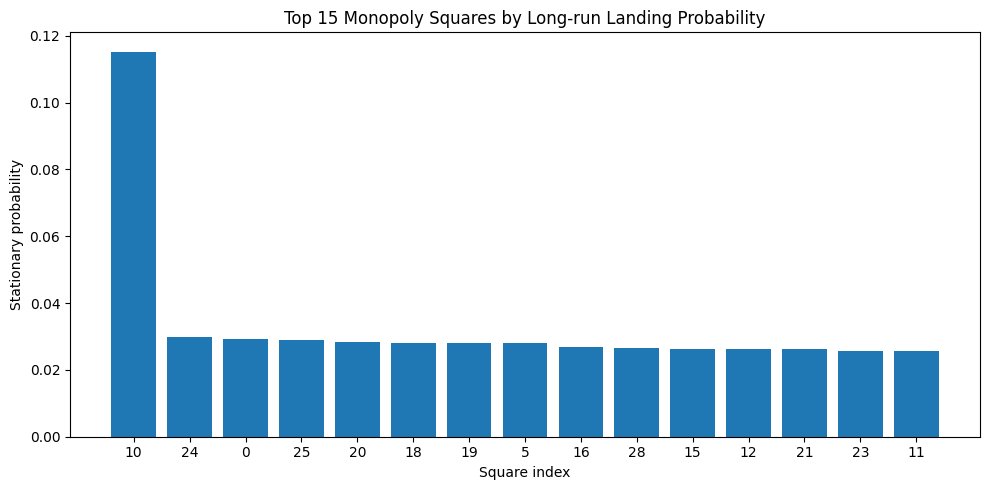

In [92]:
import matplotlib.pyplot as plt

top_k = 15
top_idx = np.argsort(-pi_board)[:top_k]
top_probs = pi_board[top_idx]

plt.figure(figsize=(10, 5))
plt.bar(range(top_k), top_probs)
plt.xticks(range(top_k), [str(i) for i in top_idx], rotation=0)
plt.ylabel("Stationary probability")
plt.xlabel("Square index")
plt.title(f"Top {top_k} Monopoly Squares by Long-run Landing Probability")
plt.tight_layout()
plt.show()

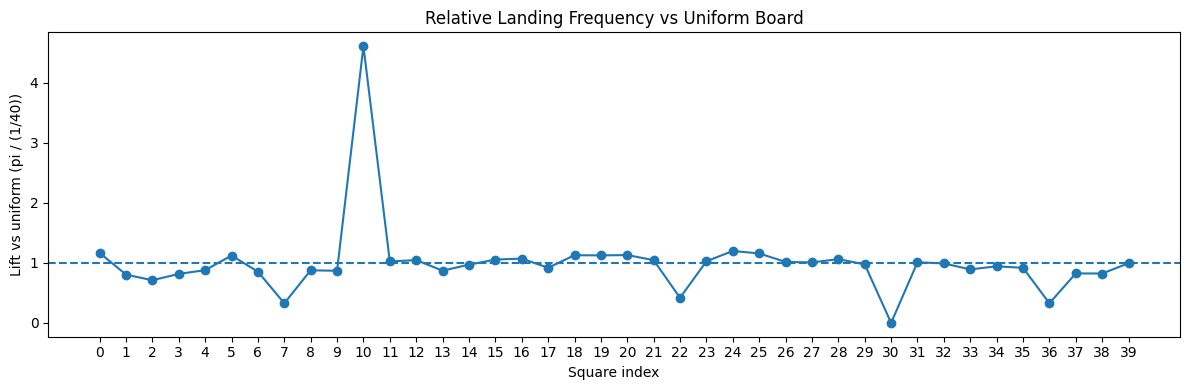

In [93]:
uniform = 1 / NUM_POS
lift = pi_board / uniform  # >1 means more than uniform

plt.figure(figsize=(12, 4))
plt.plot(range(NUM_POS), lift, marker="o")
plt.axhline(1.0, linestyle="--")
plt.xticks(range(NUM_POS), [str(i) for i in range(NUM_POS)], rotation=0)
plt.ylabel("Lift vs uniform (pi / (1/40))")
plt.xlabel("Square index")
plt.title("Relative Landing Frequency vs Uniform Board")
plt.tight_layout()
plt.show()

In [98]:
## Note: The code for plotting below is AI generated

import matplotlib.patches as patches

def plot_monopoly_style(vals, title, exclude_jail=False,
                        corner=1.2, line_width=1.0,
                        outer_lw=1.6, L=10.0,
                        save_path=None):

    v = np.array(vals, dtype=float).copy()
    if exclude_jail:
        v[JAIL] = np.nan

    cmap = plt.cm.viridis
    vmin = np.nanmin(v)
    vmax = np.nanmax(v)

    fig, ax = plt.subplots(figsize=(8.5, 8.5))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for sq in range(NUM_POS):
        if np.isnan(v[sq]):
            continue

        x, y, w, h = square_rect_monopoly(sq, L=L, corner=corner)
        t = (v[sq] - vmin) / (vmax - vmin) if vmax > vmin else 0.5

        ax.add_patch(
            patches.Rectangle(
                (x, y), w, h,
                facecolor=cmap(t),
                edgecolor="black",
                linewidth=line_width,
                joinstyle="miter"
            )
        )

    ax.add_patch(
        patches.Rectangle((0, 0), L, L,
                          fill=False, edgecolor="black",
                          linewidth=outer_lw)
    )

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Lift (π / 1/40)")

    ax.set_xlim(-0.3, L + 0.3)
    ax.set_ylim(-0.3, L + 0.3)

    # ---- Save if path provided ----
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

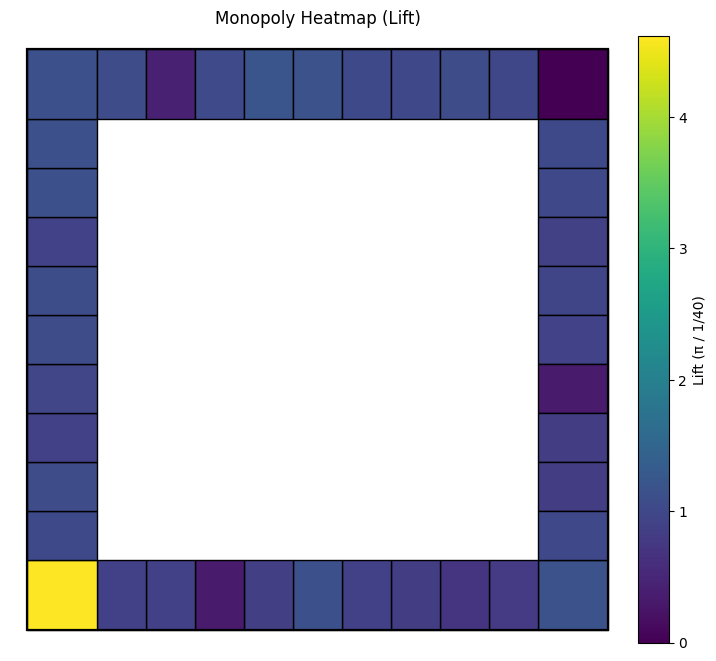

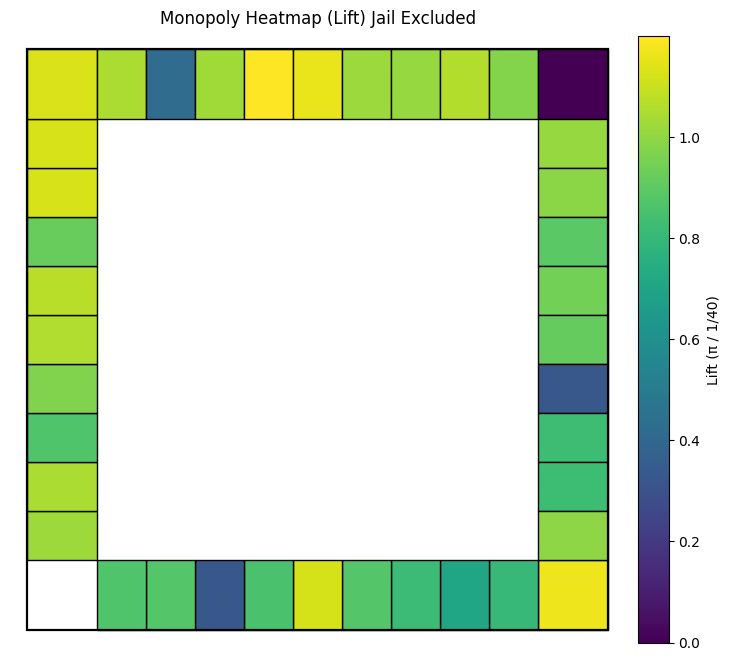

In [97]:
plot_monopoly_style(
    lift,
    "Monopoly Heatmap (Lift)",
    exclude_jail=False,
    corner=1.2,
    save_path="monopoly_heatmap_jail_included.png"
)

plot_monopoly_style(
    lift,
    "Monopoly Heatmap (Lift) Jail Excluded",
    exclude_jail=True,
    corner=1.2,
    save_path="monopoly_heatmap_jail_excluded.png"
)